# Tomato Disease Dataset Exploration

This notebook inspects the dataset used by the ResNet-50 CNN classifier. It does not train a model.

In [6]:
from collections import Counter
from pathlib import Path
import sys
from PIL import Image, ImageDraw
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'dataset').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.preprocess import CLASS_NAMES, DATASET_PATH, IMAGE_TRAIN, IMAGE_VAL, LABEL_TRAIN, LABEL_VAL, get_image_files, get_label_path, read_yolo_label
print('Project root:', PROJECT_ROOT)
print('Dataset path:', DATASET_PATH)

Project root: s:\S7 PROJECT MAIN
Dataset path: S:\S7 PROJECT MAIN\dataset\tomato_yolo_dataset


## Dataset structure and file matching

In [7]:
required = {'dataset': DATASET_PATH, 'train images': IMAGE_TRAIN, 'validation images': IMAGE_VAL, 'train labels': LABEL_TRAIN, 'validation labels': LABEL_VAL}
for name, path in required.items():
    print(f'{name:18} exists={path.exists()} path={path}')

def inventory(image_dir, label_dir):
    images = get_image_files(image_dir)
    image_stems = {path.stem for path in images}
    label_stems = {path.stem for path in label_dir.glob('*.txt')}
    return {'images': len(images), 'labels': len(label_stems), 'matched': len(image_stems & label_stems), 'missing_labels': len(image_stems - label_stems), 'orphan_labels': len(label_stems - image_stems)}

for split, image_dir, label_dir in [('train', IMAGE_TRAIN, LABEL_TRAIN), ('validation', IMAGE_VAL, LABEL_VAL)]:
    print(split, inventory(image_dir, label_dir))

dataset            exists=True path=S:\S7 PROJECT MAIN\dataset\tomato_yolo_dataset
train images       exists=True path=S:\S7 PROJECT MAIN\dataset\tomato_yolo_dataset\images\train
validation images  exists=True path=S:\S7 PROJECT MAIN\dataset\tomato_yolo_dataset\images\val
train labels       exists=True path=S:\S7 PROJECT MAIN\dataset\tomato_yolo_dataset\labels\train
validation labels  exists=True path=S:\S7 PROJECT MAIN\dataset\tomato_yolo_dataset\labels\val
train {'images': 14526, 'labels': 14526, 'matched': 14526, 'missing_labels': 0, 'orphan_labels': 0}
validation {'images': 3632, 'labels': 3632, 'matched': 3632, 'missing_labels': 0, 'orphan_labels': 0}


## Label quality and class balance

The classifier uses the first annotation class when a label file contains multiple objects.

In [8]:
for split, image_dir, label_dir in [('train', IMAGE_TRAIN, LABEL_TRAIN), ('validation', IMAGE_VAL, LABEL_VAL)]:
    status = Counter()
    classes = Counter()
    objects = 0
    multi_object = 0
    for image_path in get_image_files(image_dir):
        label_path = get_label_path(image_path, label_dir)
        if not label_path.exists():
            status['missing'] += 1
            continue
        try:
            labels = read_yolo_label(label_path)
        except (OSError, ValueError) as error:
            status['invalid'] += 1
            print(f'Invalid label {label_path.name}: {error}')
            continue
        if not labels:
            status['empty'] += 1
            continue
        status['valid'] += 1
        objects += len(labels)
        multi_object += int(len(labels) > 1)
        classes.update(label['class_id'] for label in labels)
    print(f'{split}: status={dict(status)}, objects={objects}, multi_object_images={multi_object}')
    for class_id, class_name in CLASS_NAMES.items():
        print(f'  {class_id}: {class_name}: {classes[class_id]}')

train: status={'valid': 14526}, objects=14541, multi_object_images=14
  0: Bacterial spot: 1700
  1: Early blight: 785
  2: Late blight: 1531
  3: Leaf Mold: 761
  4: Septoria leaf spot: 1431
  5: Spider mites: 1356
  6: Target Spot: 1113
  7: Tomato Yellow Leaf Curl Virus: 4277
  8: Tomato mosaic virus: 301
  9: Healthy: 1286
validation: status={'valid': 3632}, objects=3638, multi_object_images=6
  0: Bacterial spot: 427
  1: Early blight: 219
  2: Late blight: 380
  3: Leaf Mold: 191
  4: Septoria leaf spot: 347
  5: Spider mites: 321
  6: Target Spot: 292
  7: Tomato Yellow Leaf Curl Virus: 1084
  8: Tomato mosaic virus: 72
  9: Healthy: 305


## Image dimensions and readable files

In [9]:
for split, image_dir in [('train', IMAGE_TRAIN), ('validation', IMAGE_VAL)]:
    dimensions = Counter()
    modes = Counter()
    unreadable = []
    for image_path in get_image_files(image_dir):
        try:
            with Image.open(image_path) as image:
                image.verify()
            with Image.open(image_path) as image:
                dimensions[image.size] += 1
                modes[image.mode] += 1
        except (OSError, ValueError) as error:
            unreadable.append((image_path.name, str(error)))
    print(f'{split}: readable={sum(dimensions.values())}, modes={dict(modes)}')
    print('  common dimensions:', dimensions.most_common(10))
    print('  unreadable:', len(unreadable))
    for name, error in unreadable[:5]:
        print('   ', name, error)

train: readable=14526, modes={'RGB': 14526}
  common dimensions: [((256, 256), 14526)]
  unreadable: 0
validation: readable=3632, modes={'RGB': 3632}
  common dimensions: [((256, 256), 3632)]
  unreadable: 0


## Visualize representative images and YOLO boxes

TMBS_image (1).jpg : Bacterial spot


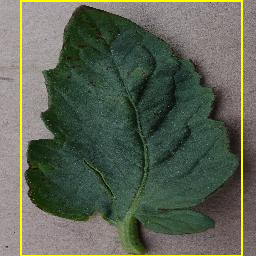

TMBS_image (10).jpg : Bacterial spot


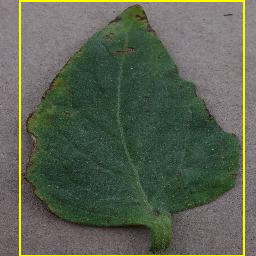

TMBS_image (100).jpg : Bacterial spot


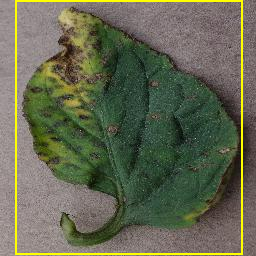

TMBS_image (1000).jpg : Bacterial spot


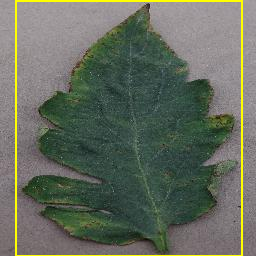

TMBS_image (1001).jpg : Bacterial spot


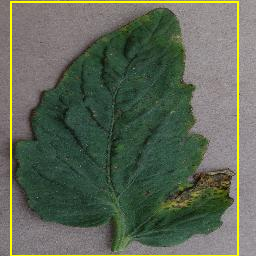

TMBS_image (1003).jpg : Bacterial spot


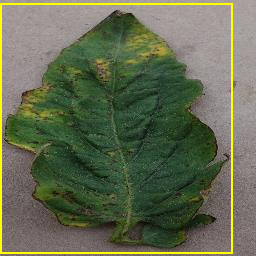

In [10]:
def preview_images(image_dir, label_dir, count=6):
    for image_path in get_image_files(image_dir)[:count]:
        with Image.open(image_path).convert('RGB') as source:
            image = source.copy()
        draw = ImageDraw.Draw(image)
        width, height = image.size
        names = []
        for label in read_yolo_label(get_label_path(image_path, label_dir)):
            center_x = label['x_center'] * width
            center_y = label['y_center'] * height
            box_width = label['width'] * width
            box_height = label['height'] * height
            draw.rectangle((center_x - box_width / 2, center_y - box_height / 2, center_x + box_width / 2, center_y + box_height / 2), outline='yellow', width=max(2, width // 300))
            names.append(CLASS_NAMES.get(label['class_id'], 'unknown'))
        print(image_path.name, ':', ', '.join(names) or 'no label')
        display(image)

preview_images(IMAGE_TRAIN, LABEL_TRAIN)

## Final checklist

Confirm that directories exist, image and label stems match, labels are valid, all classes have examples, images are readable, and displayed boxes match the images. For strict validation run `python src\\preprocessing\\preprocess.py` from the project root.